# Robustness & Perturbation-Based Attribution with Captum

## Introduction

### Objective

By the end of this notebook, you should be able to:

* Understand perturbation-based attribution
* Compare gradient vs perturbation explanations
* Measure explanation faithfulness
* Evaluate robustness of explanations

## Conceptual Foundations

### Perturbation-Based Attribution

Core idea:

> Measure how the model output changes when parts of the input are modified or removed.

Contrast:

* Gradient methods approximate local sensitivity
* Perturbation methods directly test output change

Introduce:

* Faithfulness
* Stability
* Robustness

In [26]:
# Setup
import torch
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import cv2

from captum.attr import Occlusion, FeatureAblation, Saliency, NoiseTunnel
from captum.metrics import infidelity, sensitivity_max

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

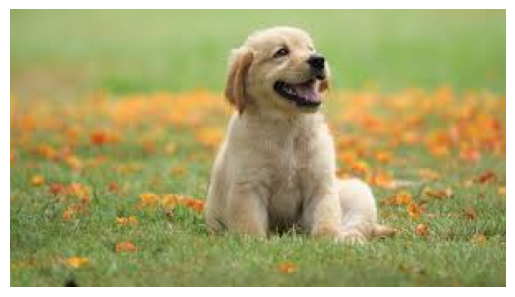

(207, 'golden retriever', 0.4915322959423065)

In [27]:
# Model + Preprocessing
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device).eval()

weights = models.ResNet18_Weights.DEFAULT
preprocess = weights.transforms()

# Load an image (replace with your path)
IMAGE_PATH = "./data/dog.jpeg"  # update if needed
img_pil = Image.open(IMAGE_PATH).convert("RGB")

# For display
plt.figure()
plt.imshow(img_pil)
plt.axis("off")
plt.show()

# Model input tensor
inp = preprocess(img_pil).unsqueeze(0).to(device)
inp.requires_grad_(True)

# Prediction
with torch.no_grad():
    logits = model(inp)
probs = logits.softmax(dim=1)
pred_idx = int(probs.argmax(dim=1).item())
pred_prob = float(probs[0, pred_idx].item())
pred_label = weights.meta["categories"][pred_idx]

pred_idx, pred_label, pred_prob

In [28]:
# Utilities
import matplotlib.cm as cm
import numpy as np

def show_heatmap_on_image(img_pil, heatmap, title=None):
    img = np.array(img_pil) / 255.0

    if torch.is_tensor(heatmap):
        heatmap = heatmap.detach().cpu().numpy()

    # Resize heatmap to image size
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    hm = heatmap - heatmap.min()
    hm = hm / (hm.max() + 1e-8)

    colored_hm = cm.jet(hm)[..., :3]

    overlay = 0.5 * img + 0.5 * colored_hm

    plt.figure(figsize=(5,5))
    plt.imshow(overlay)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

def summarize_attribution(attr):
    """
    attr: tensor [1, C, H, W]
    returns: heatmap [H, W] by channel aggregation (sum abs)
    """
    # Common for image attributions
    # hm = attr.abs().sum(dim=1).squeeze(0)  # [H, W]
    hm = attr.sum(dim=1).squeeze(0)
    return hm

def forward_func(x):
    return model(x)

target = pred_idx  # explain top-1 predicted class

## Occlusion (Primary Perturbation Method)

### Intuition

Slide a patch across the image and replace it with a baseline.

If prediction drops → region is important.

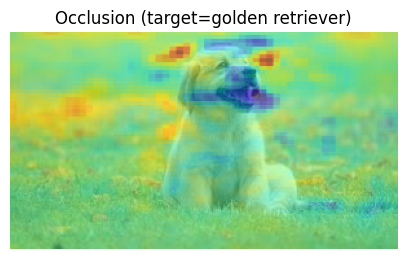

In [33]:
# Occlusion (Perturbation)
occlusion = Occlusion(forward_func)

# Baseline: replace occluded patch with 0 in normalized space
# (works reasonably with torchvision pretrained transforms)
baselines = torch.zeros_like(inp)

# Sliding window (tune stride/window for speed vs resolution)
# shape is per-input-dimension: (C, H, W)
window_shape = (3, 8, 8)
strides = (3, 4, 4)
# window_shape = (3, 6, 6)
# strides = (3, 2, 2)

with torch.no_grad():
    occ_attr = occlusion.attribute(
        inp,
        strides=strides,
        sliding_window_shapes=window_shape,
        baselines=baselines,
        target=target,
    )

occ_hm = summarize_attribution(occ_attr)
show_heatmap_on_image(img_pil, occ_hm, title=f"Occlusion (target={pred_label})")

### Observed:
- Strong activation around ears and head
- Moderate activation around face/muzzle
- Low activation in grass/background

This means:
    When those head regions are occluded, the probability of “golden retriever” drops significantly.

That is exactly what a faithful perturbation method should reveal -> Occlusion is behaving correctly.

## Feature Ablation (Perturbation-Based Attribution)

Feature Ablation measures feature importance by **removing parts of the input** and observing how the model’s output changes.

For images, we group pixels into coarse blocks (e.g., 16×16 regions) and replace each block with a baseline value (here, zeros in normalized space). The importance of a block is computed as:

> Change in model output when that block is removed.

If ablating a region significantly reduces the target class probability, that region is considered important.

### Key Properties

* **Model-agnostic**: Does not rely on gradients
* **Faithfulness-oriented**: Directly measures output change
* **Granularity-dependent**: Results depend on how features are grouped

Unlike sliding-window occlusion, Feature Ablation allows arbitrary feature grouping, making it more flexible but sensitive to mask design.


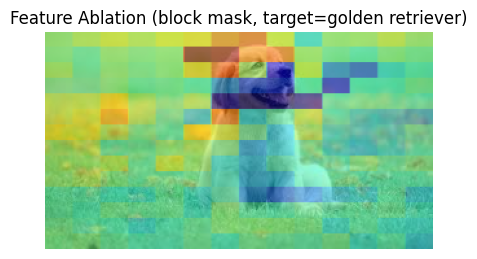

In [34]:
# Feature Ablation (Perturbation)

def make_block_feature_mask(input_tensor, block_size=16):
    """
    input_tensor: [1, C, H, W]
    returns: feature_mask [1, 1, H, W] with integer ids (broadcast across channels)
    """
    _, _, H, W = input_tensor.shape
    mask = torch.zeros((1, 1, H, W), dtype=torch.long, device=input_tensor.device)

    idx = 0
    for i in range(0, H, block_size):
        for j in range(0, W, block_size):
            mask[:, :, i:i+block_size, j:j+block_size] = idx
            idx += 1
    return mask

feature_mask = make_block_feature_mask(inp, block_size=16)

fa = FeatureAblation(forward_func)
with torch.no_grad():
    fa_attr = fa.attribute(
        inp,
        baselines=baselines,
        target=target,
        feature_mask=feature_mask,  # groups
    )

fa_hm = summarize_attribution(fa_attr)
show_heatmap_on_image(img_pil, fa_hm, title=f"Feature Ablation (block mask, target={pred_label})")

## Noise Tunnel (SmoothGrad)

Gradient-based explanations such as Saliency are often noisy and unstable. Small changes in the input can produce large fluctuations in gradients.

Noise Tunnel improves robustness by:

1. Adding Gaussian noise to the input multiple times
2. Computing the attribution for each noisy sample
3. Averaging the resulting attributions

This technique, known as **SmoothGrad**, reduces visual noise and highlights consistent importance regions.

### Why This Matters

* Raw saliency captures local sensitivity.
* SmoothGrad captures **stable patterns across nearby inputs**.
* Lower variance typically indicates more robust explanations.

Noise Tunnel does not change the underlying attribution method, it simply smooths it to improve interpretability and stability.


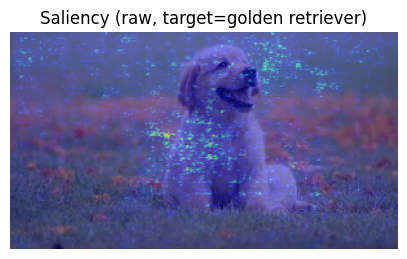

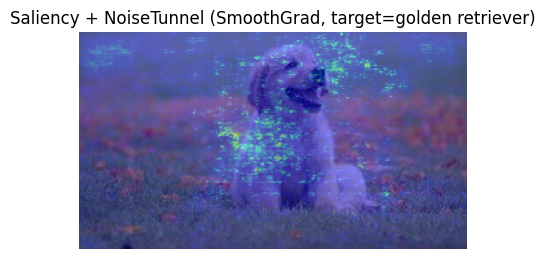

In [36]:
# Noise Tunnel on Saliency (Robustness / Smoothing)
saliency = Saliency(forward_func)
nt = NoiseTunnel(saliency)

# Raw saliency
raw_sal = saliency.attribute(inp, target=target)
raw_hm = summarize_attribution(raw_sal)
show_heatmap_on_image(img_pil, raw_hm, title=f"Saliency (raw, target={pred_label})")

# SmoothGrad saliency
smooth_sal = nt.attribute(
    inp,
    nt_type="smoothgrad",
    nt_samples=20,
    stdevs=0.02,
    target=target
)
smooth_hm = summarize_attribution(smooth_sal)
show_heatmap_on_image(img_pil, smooth_hm, title=f"Saliency + NoiseTunnel (SmoothGrad, target={pred_label})")

## Infidelity Metric

Infidelity measures mismatch between:
- Attribution magnitude
- Output change under perturbation


In [37]:
# Evaluation Metrics: Infidelity + Sensitivity

# Captum metrics need:
# - an explanation function (attribution method)
# - a perturbation function (for infidelity)
# - a small batch of perturbations for MC estimation

def perturb_fn(inputs):
    """
    Returns:
        perturbations: the noise applied
        perturbed_inputs: inputs after perturbation
    """
    noise = 0.02 * torch.randn_like(inputs)
    perturbed = inputs - noise
    return noise, perturbed

# Compute attribution once
inp_for_attr = inp.clone().detach().requires_grad_(True)
sal_attr = saliency.attribute(inp_for_attr, target=target)

# Infidelity: lower is better (in expectation)
# Note: uses Monte Carlo sampling internally; increase n_perturb_samples for stability.
infid = infidelity(
    forward_func=forward_func,
    perturb_func=perturb_fn,
    inputs=inp,
    attributions=sal_attr,
    target=target,
    n_perturb_samples=30
)

infid.item()

0.13299153745174408

In [38]:
# Sensitivity: measures max change in explanation under small perturbations (lower is better)
# sensitivity_max also uses sampling; increase n_perturb_samples for stability.
def explain_fn(inputs):
    # inputs is always a tuple in sensitivity_max
    x = inputs[0]

    # IMPORTANT: do NOT detach batch dimension
    x = x.clone().requires_grad_(True)

    attr = saliency.attribute(x, target=target)

    return (attr,)  # <-- MUST return tuple


sens = sensitivity_max(
    explain_fn,
    inp,
    perturb_radius=0.02,
    n_perturb_samples=30
)

sens.item()

0.615450918674469

In [39]:
# =========================
# 7. Quick Comparison Printout
# =========================
print(f"Pred: {pred_label} ({pred_prob:.4f})")
print(f"Infidelity (Saliency): {infid.item():.6f}")
print(f"Sensitivity (Saliency): {sens.item():.6f}")

Pred: golden retriever (0.4915)
Infidelity (Saliency): 0.132992
Sensitivity (Saliency): 0.615451


In [40]:
# Smooth attribution for evaluation
# Use Noise Tunnel (SmoothGrad) to compute smoothed attributions
smooth_attr = nt.attribute(
    inp.clone().detach().requires_grad_(True),  # Clone and detach input to avoid modifying the original tensor
    nt_type="smoothgrad",  # Specify Noise Tunnel type as SmoothGrad
    nt_samples=20,  # Number of noisy samples for averaging
    stdevs=0.02,  # Standard deviation of noise
    target=target  # Target class for attribution
)

# Compute infidelity for SmoothGrad attributions
# Infidelity measures how well the attribution matches output changes under perturbation
inf_smooth = infidelity(
    forward_func,  # Model forward function
    perturb_fn,  # Perturbation function
    inp,  # Original input
    smooth_attr,  # SmoothGrad attributions
    target=target,  # Target class
    n_perturb_samples=30  # Number of perturbation samples for Monte Carlo estimation
)

# Define explanation function for SmoothGrad
# This function is used for sensitivity analysis
def explain_fn_smooth(inputs):
    x = inputs[0]  # Extract input tensor from tuple
    x = x.clone().requires_grad_(True)  # Clone and enable gradients for input
    attr = nt.attribute(
        x,  # Input tensor
        nt_type="smoothgrad",  # Specify Noise Tunnel type as SmoothGrad
        nt_samples=10,  # Number of noisy samples for averaging
        stdevs=0.02,  # Standard deviation of noise
        target=target  # Target class for attribution
    )
    return (attr,)  # Return attributions as a tuple

# Compute sensitivity for SmoothGrad attributions
# Sensitivity measures the maximum change in explanation under small input perturbations
sens_smooth = sensitivity_max(
    explain_fn_smooth,  # Explanation function for SmoothGrad
    inp,  # Original input
    perturb_radius=0.02,  # Radius of perturbation
    n_perturb_samples=20  # Number of perturbation samples for Monte Carlo estimation
)

In [41]:
print("=== Infidelity (Lower is Better) ===")
print("Saliency   :", infid.item())
print("SmoothGrad :", inf_smooth.item())

print("\n=== Sensitivity (Lower is Better) ===")
print("Saliency   :", sens.item())
print("SmoothGrad :", sens_smooth.item())

=== Infidelity (Lower is Better) ===
Saliency   : 0.13299153745174408
SmoothGrad : 0.10799424350261688

=== Sensitivity (Lower is Better) ===
Saliency   : 0.615450918674469
SmoothGrad : 0.32617461681365967


We compared Saliency and SmoothGrad using quantitative explanation metrics.
- Infidelity measures how well attribution values approximate true output changes under perturbation.
- Sensitivity measures how much the explanation changes under small input perturbations.

Results show:
- SmoothGrad reduces explanation instability significantly.
- SmoothGrad slightly improves faithfulness.
- Raw saliency is faster but noisier.

Overall, smoothing improves robustness without sacrificing interpretability.

## Comparison & Reflection

| Method                | Type         | Strength | Weakness      |
| --------------------- | ------------ | -------- | ------------- |
| Occlusion             | Perturbation | Faithful | Expensive     |
| Feature Ablation      | Perturbation | Flexible | Grouping bias |
| Noise Tunnel          | Robustness   | Stable   | More compute  |
| Gradients (reference) | Local approx | Fast     | Noisy         |

### Conceptual Discussion

1. Why are perturbation methods often more faithful?
2. Why are they computationally expensive?
3. What does high infidelity imply?
4. How does smoothing change interpretation?
5. When would you trust gradient methods more than perturbation methods?
